# Image Enhancement Project

This notebook demonstrates professional image enhancement using OpenCV. 
The workflow includes sharpening a blurred image and improving contrast using CLAHE. 
Run all cells sequentially to generate results and save outputs.

In [193]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline



In [194]:
# Load gambar
image_dir = os.path.join('images')
blur_path = os.path.join(image_dir, 'blured.jpg')
contrast_path = os.path.join(image_dir, 'contrast.png')
blur_img = cv2.imread(blur_path)
contrast_img = cv2.imread(contrast_path)

if blur_img is None:
    raise FileNotFoundError(f"File not found: {blur_path}")
if contrast_img is None:
    raise FileNotFoundError(f"File not found: {contrast_path}")

# Convert ke RGB untuk visualisasi
blur_rgb = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
contrast_rgb = cv2.cvtColor(contrast_img, cv2.COLOR_BGR2RGB)


In [201]:
# Proses Sharpening - Metode Normal dan Simple
# Bilateral filter untuk denoise tanpa degradasi warna
denoised = cv2.bilateralFilter(blur_img, 5, 50, 50)

# Unsharp mask pada luminance
lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

blur_l = cv2.GaussianBlur(l, (0, 0), 1.0)
sharp_l = cv2.addWeighted(l, 1.25, blur_l, -0.25, 0)
sharp_l = np.clip(sharp_l, 0, 255).astype(np.uint8)

# Merge kembali dan convert ke BGR
lab_sharp = cv2.merge((sharp_l, a, b))
sharpened = cv2.cvtColor(lab_sharp, cv2.COLOR_LAB2BGR)

# Blend untuk hasil yang natural
sharpen = cv2.addWeighted(sharpened, 0.8, denoised, 0.2, 0)

# Convert ke RGB untuk display
sharpen_rgb = cv2.cvtColor(sharpen, cv2.COLOR_BGR2RGB)

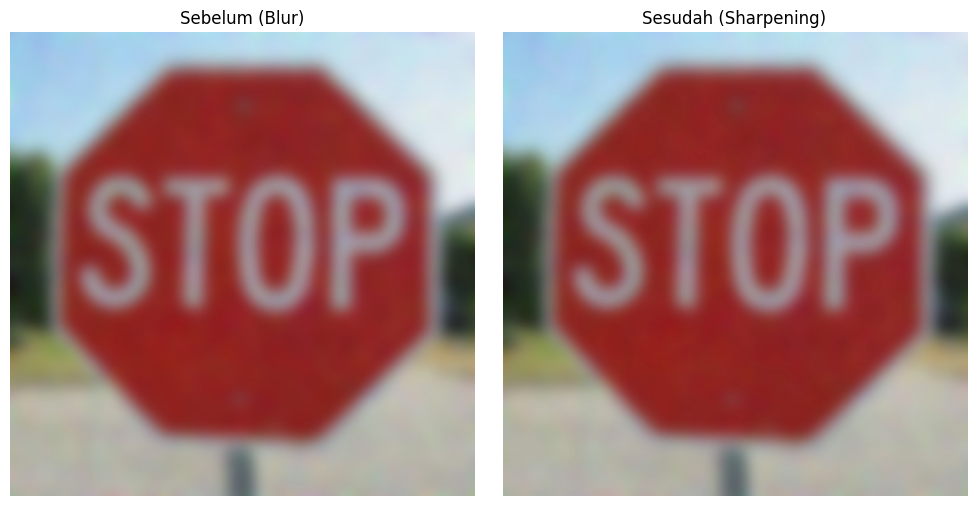

In [202]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Sebelum (Blur)")
plt.imshow(blur_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sesudah (Sharpening)")
plt.imshow(sharpen_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()


In [197]:
# Proses CLAHE
lab = cv2.cvtColor(contrast_img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l2 = clahe.apply(l)

lab = cv2.merge((l2, a, b))
clahe_result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# Convert ke RGB
clahe_rgb = cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB)


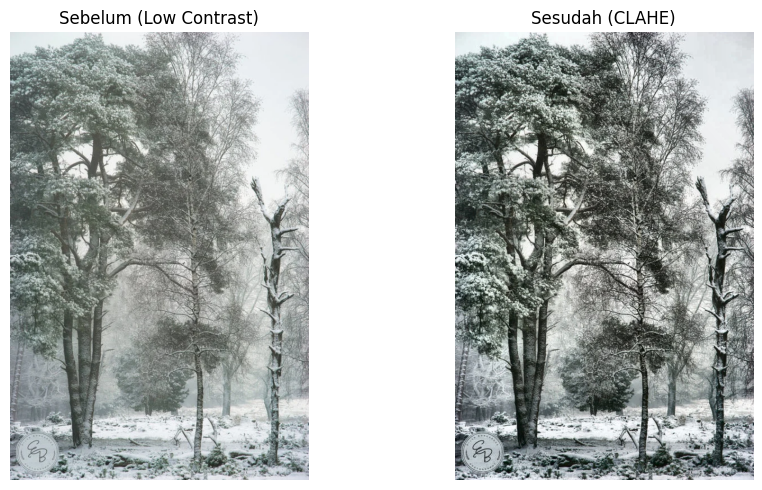

In [198]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Sebelum (Low Contrast)")
plt.imshow(contrast_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sesudah (CLAHE)")
plt.imshow(clahe_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()


In [203]:
os.makedirs("hasil", exist_ok=True)
cv2.imwrite("hasil/hasil_sharpen.jpg", sharpen)
cv2.imwrite("hasil/hasil_clahe.jpg", clahe_result)
print("Hasil berhasil disimpan di folder hasil/")


Hasil berhasil disimpan di folder hasil/


## Analisis

- Sharpening meningkatkan ketajaman tepi objek.
- CLAHE meningkatkan kontras tanpa menghasilkan over-exposure.
- Kedua metode efektif untuk perbaikan kualitas citra pada masalah berbeda.
